Udacity Pytorch project 2: CIFAR-10 Image Classification

Some of the benchmark results on CIFAR-10 include:

 

78.9% Accuracy | [Deep Belief Networks; Krizhevsky, 2010](https://www.cs.toronto.edu/~kriz/conv-cifar10-aug2010.pdf)

 

90.6% Accuracy | [Maxout Networks; Goodfellow et al., 2013](https://arxiv.org/pdf/1302.4389.pdf)

 

96.0% Accuracy | [Wide Residual Networks; Zagoruyko et al., 2016](https://arxiv.org/pdf/1605.07146.pdf)

 

99.0% Accuracy | [GPipe; Huang et al., 2018](https://arxiv.org/pdf/1811.06965.pdf)

 

98.5% Accuracy | [Rethinking Recurrent Neural Networks and other Improvements for ImageClassification; Nguyen et al., 2020](https://arxiv.org/pdf/2007.15161.pdf)

In [1]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transform
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets
from torch.utils.data import DataLoader
import sys 
from torchinfo import summary


In [2]:
BATCH_SIZE = 4
DEVICE = 'cpu'

Load the Dataset

Specific your transforms as a list first. The transforms module is already loaded as transforms
CIFAR-10 is fortunately included in the torchvision module. Then you can create your dataset using the CIFAR10 object from torchvision.datasets. Make sure to specify download=True. 
Once your dataset is created, you'll also need to define a Dataloader from the torch.utils.data module for both train and test set



In [3]:
#Define transforms

# TODO: Define transforms for the training data and testing data
#these transforms are tentative!! Putting something in to get the ball rolling. They may very well suck. 
train_transforms = transform.Compose([ transform.RandomHorizontalFlip(),
                                       transform.ToTensor()]) 

test_transforms =  transform.Compose([   transform.ToTensor()])





#Create training set and define training data loader
#changing batch size from 64 to 32. not sure if I'll need to use a GPU or not. 
trainset = datasets.CIFAR10('data/', download=True, train=True, transform=train_transforms)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)



#Create your test set and define test data loader
testset = datasets.CIFAR10('data/', download=True, train=False, transform=test_transforms)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=True)

trainsetview = datasets.CIFAR10('data/', download=True, train=True)
trainloaderview = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)



#the 10 classes in the dataset
classes=('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')


Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified


In [4]:
class_names = trainset.classes
class_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

Explore the Dataset

Using matplotlib, numpy and torch, explore the dimensions of your data 

you can view images using the show5 function below - it takes a dataloader as an argument. Remember that normalized images will look really weird to you. You may want to try changing your transforms to view images.Typically using no transforms other than toTensor() works well for viewing - but not as well for training your network. If show5 doesn't work, go back and check your code for creating your dataloaders and your training/test sets.


In [5]:
print(len(trainset.data))
print(len(trainset.targets))
print(len(testset.data))
print(len(testset.targets))


50000
50000
10000
10000


In [6]:
class_names = trainset.classes
class_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [7]:
#TODO I need to add dataloaders for train and test.  

In [8]:

# train_dl = DataLoader(trainset, 
#     batch_size=BATCH_SIZE,  
#     shuffle=True )
# print(len(train_dl))
# test_dl = DataLoader(testset,
#     batch_size=BATCH_SIZE,
#     shuffle=False 
# )
# print(len(test_dl))
# print("check for len match:",len(train_dl)*BATCH_SIZE)
# print("check for len match:",len(test_dl)*BATCH_SIZE)
# #note: last set less than 64 count, hence multiplying the above overcounts one batch.
# print(len(trainset)/len(train_dl))
# print((len(trainset)/len(train_dl)-63)*BATCH_SIZE)


In [9]:
def show5(img_loader):
    dataiter=iter(img_loader)

    batch=next(dataiter)
    labels=batch[1][0:5]
    image=batch[0][0:5]
    for i in range(5):
        print(classes[labels[i]])
        image=images[i].numpy()
        plt.imshow(image.T)
        plt.show()
    

plane


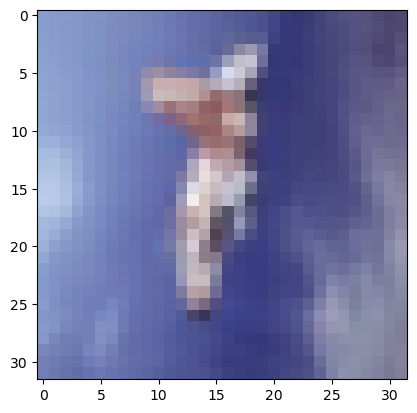

cat


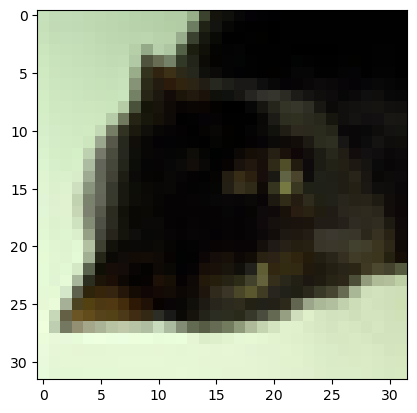

plane


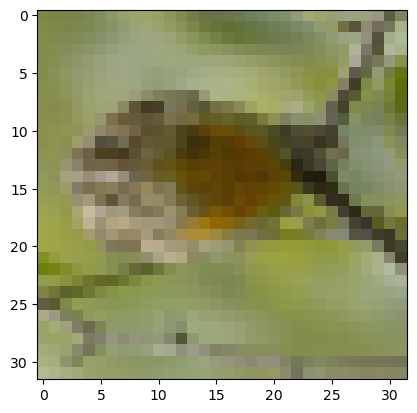

car


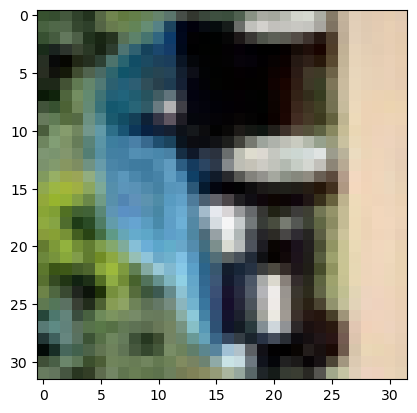

IndexError: index 4 is out of bounds for dimension 0 with size 4

In [10]:

#loading in new variables for viewing 

# train_view_transforms = transform.Compose([transform.ToTensor()]) 
# #not needed 
# #test_view_transforms =  transform.Compose([ transform.ToTensor()])

# trainviewset = datasets.CIFAR10('data/', download=True, train=True, transform=train_view_transforms)
# trainviewloader = torch.utils.data.DataLoader(trainviewset, batch_size=BATCH_SIZE, shuffle=True)

# dataiter=iter(trainviewloader)
# batch=next(dataiter)
# labels=batch[1][0:5]
# image=batch[0][0:5]
# for i in range(5):
#     print(classes[labels[i]])
#     image=images[i].numpy()
#     plt.imshow(image.T)
#     plt.show()

# Run this to test your data loader
images, labels = next(iter(trainloaderview))
#helper.imshow(images[0], normalize=False)    

dataiter=iter(trainloaderview)
batch=next(dataiter)
labels=batch[1][0:5]
image=batch[0][0:5]
for i in range(5):
    print(classes[labels[i]])
    image=images[i].numpy()
    plt.imshow(image.T)
    plt.show()


In [11]:
#explore data
image, label = next(iter(trainviewloader))
#image.shape
print(image[0][0].shape)
show5(trainviewloader)


NameError: name 'trainviewloader' is not defined

Build your Neural Network

Using the layers in torch.nn (which has been imported as nn) and the torch.nn.Functional module (imported as F)
construct a neural network based on the parameters of the dataset. Feel free to consult a model of any architecture-feedforward, convolutional or even something more advanced.

In [12]:
#do more exploring... need to get proper shape before building the network. 
dataiter = iter(trainloader)
images, labels = next(dataiter)
print(type(images))
print(images.shape)
print(labels.shape)
print(len(images))
print(len(dataiter))





<class 'torch.Tensor'>
torch.Size([4, 3, 32, 32])
torch.Size([4])
4
12500


In [17]:
32*32

1024

In [14]:
#REFERENCE https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
#torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, groups=1, bias=True, padding_mode='zeros', device=None, dtype=None)

In [18]:
#code here to build the network 
#placeholder model. no commitment to keep this. again, this won't work as the shape does not fit the cifar10 data
#added dropout. 20% to start 
class Classifier(nn.Module):
    def __init__(self,input_shape):
        super().__init__()
        
        #self.fc0 = nn.AdaptiveMaxPool2d(output_size=512)
        
        #self.fc0 = nn.Conv2d(in_channels=input_shape,out_channels=224,kernel_size=3)
        self.fc1 = nn.Linear(1024, 64)
        
        self.fc2 = nn.Linear(64, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)
        self.dropoutprobability = 0
        #self.dropout = nn.Dropout(self.dropoutprobability) 
        
    def forward(self, x):
        # make sure input tensor is flattened
        x = x.view(x.shape[0], -1)
        #x = F.relu(self.fc0(x))
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.log_softmax(self.fc4(x), dim=1)
        
        return x

In [20]:
 
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 10)
 
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 32 * 32)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [21]:
#testing 
c = Net()
#c.dropoutprobability=0.2
#take 1 image
image, label = next(iter(dataiter))
print(type(image))
print(image.shape)
print(label.shape)
print(len(image))
one_image, one_label = image[0].unsqueeze(dim=0), label[0]
print(type(one_image))
print(one_image.shape)
print(label.shape)
print(len(one_image))
c.eval() # put in test mode
# with torch.inference_mode():
#     pred = c(one_image.to(DEVICE))
#     print(pred)


<class 'torch.Tensor'>
torch.Size([4, 3, 32, 32])
torch.Size([4])
4
<class 'torch.Tensor'>
torch.Size([1, 3, 32, 32])
torch.Size([4])
1


Net(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=32768, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [22]:
summary(c)

Layer (type:depth-idx)                   Param #
Net                                      --
├─Conv2d: 1-1                            448
├─MaxPool2d: 1-2                         --
├─Conv2d: 1-3                            4,640
├─Linear: 1-4                            4,194,432
├─Linear: 1-5                            1,290
Total params: 4,200,810
Trainable params: 4,200,810
Non-trainable params: 0

In [23]:
#TEMP cell 
device = 'cpu'
# 1. Get a batch of images and labels from the DataLoader
img_batch, label_batch = next(iter(trainloader))

# 2. Get a single image from the batch and unsqueeze the image so its shape fits the model
img_single, label_single = img_batch[0].unsqueeze(dim=0), label_batch[0]
print(f"Single image shape: {img_single.shape}\n")

# 3. Perform a forward pass on a single image
c.eval()
with torch.inference_mode():
    pred = c(img_single.to(device))
    
# 4. Print out what's happening and convert model logits -> pred probs -> pred label
print(f"Output logits:\n{pred}\n")
print(f"Output prediction probabilities:\n{torch.softmax(pred, dim=1)}\n")
print(f"Output prediction label:\n{torch.argmax(torch.softmax(pred, dim=1), dim=1)}\n")
print(f"Actual label:\n{label_single}")

Single image shape: torch.Size([1, 3, 32, 32])



RuntimeError: shape '[-1, 32768]' is invalid for input of size 2048

Specify a loss function and an optimizer and instantiate the model.
if you use a less common loss function, please note why you chose that function in a comment. 

In [24]:
#code for loss fx and optimizer here
#model = c #Classifier(input_shape=3)
model = Net()
#model.dropoutprobability = 0.2
#placeholder loss function and optimizer
#criterion = nn.NLLLoss(reduction='sum')
weights = torch.ones([256]) #trying equal weights across the board 
#criterion =nn.BCEWithLogitsLoss() #bag this. wrong type here 
#criterion = nn.NLLLoss(reduction='sum') #no shape errors
#try this one 
criterion = nn.CrossEntropyLoss()
#criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)
#optimizer = optim.SGD(model.parameters(), lr=0.01)


Running your Neural Network 

use whatever method you like to train your neural network and ensure you record the average loss at each epoch. Don't forget to use torch.device() and the .to() method for both your model and data if you are using GPU

if you want to print your loss during each epoch, you can use the enumerate function and print the loss after a set of batches. 250 batches works well for most people. 

In [25]:
# for images, labels in trainloader:
#     print(images.shape)
#     log_ps = model(images)
#     print(log_ps.shape)
#     print(labels.shape)
#     #sys.exit()

In [26]:
#train network 
#beat 30.6% accuracy after 3 epochs... NEED A GPU machine... getting one this week. 

epochs = 2

for e in range(epochs):
    print('churning thru epoch number:',e)
    running_loss = 0
    model.train()
    for images, labels in trainloader:
        #labels = labels.long() #was getting a dtype error as it was float 
        #print(images.shape)
        #print(labels.shape)
        #for i in range(BATCH_SIZE):
        #one_image, one_label = images[i].unsqueeze(dim=0), labels[i]
        #images, l
        #print(one_image.shape)
        #print(one_label.shape)
        
        optimizer.zero_grad()
        #forgot to squeeze which was causing a shape mismatch... I understand how COMMON shape mismatches are now LOL! 
        log_ps = model(images) #one_image)
        #log_ps2=log_ps.squeeze(-1)
        #print('log p shape:',log_ps.shape)
        #labels = labels.float() #images are in float format
        
        #print(labels.shape)
        # print("logits2 shape:", log_ps2.shape)
        # print("targets shape:", labels.shape)
        # print("logits2 dtype:", log_ps2.dtype)
        # print("targets dtype:", labels.dtype)
        #sys.exit()
        loss = criterion(log_ps, labels)
        #sys.exit() 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    else:
        
        print(f"Training loss: {running_loss/len(trainloader)}")

churning thru epoch number: 0


RuntimeError: shape '[-1, 32768]' is invalid for input of size 8192

In [27]:
#code to run the network 

#placeholder training/testing 

# #pull from the right loader
# image, label = next(iter(trainloader))


#one epoch to start just to work out the kinks, if any
epochs = 3

train_losses, test_losses = [], []
for e in range(epochs):
    print('churning thru epoch:',e)
    tot_train_loss = 0
    model.train()
    for images, labels in trainloader:
        optimizer.zero_grad()
        #print(images.shape)
        #torch.Size([32, 3, 224, 224])
        #RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x150528 and 784x256)
        #sys.exit()
        log_ps = model(images)
        loss = criterion(log_ps, labels)
        tot_train_loss += loss.item()
        
        loss.backward()
        optimizer.step()
    else:
        tot_test_loss = 0
        test_correct = 0  # Number of correct predictions on the test set
        
        # # Turn off gradients for validation, saves memory and computations
        with torch.no_grad():
            model.eval()
            for images, labels in testloader:
                log_ps = model(images)
                loss = criterion(log_ps, labels)
                tot_test_loss += loss.item()    

                ps = torch.exp(log_ps)
                top_p, top_class = ps.topk(1, dim=1)
                equals = top_class == labels.view(*top_class.shape)
                test_correct += equals.sum().item()

        # Get mean loss to enable comparison between train and test sets
        train_loss = tot_train_loss / len(trainloader.dataset)
        test_loss = tot_test_loss / len(testloader.dataset)

        # At completion of epoch
        train_losses.append(train_loss)
        test_losses.append(test_loss)

        print("Epoch: {}/{}.. ".format(e+1, epochs),
              "Training Loss: {:.3f}.. ".format(train_loss),
              "Test Loss: {:.3f}.. ".format(test_loss),
              "Test Accuracy: {:.3f}".format(test_correct / len(testloader.dataset)))
    
print('done')

churning thru epoch: 0


RuntimeError: shape '[-1, 32768]' is invalid for input of size 8192

Plot the training loss (and validation loss/accuracy, if recorded)

In [ ]:
#showing the plots 
plt.plot(train_losses, label='Training loss')
plt.plot(test_losses, label='Validation loss')
plt.legend(frameon=False)

Testing your model 

using the previously created DataLoader for the test set, compute the percentage of correct predictions using the highest probability prediction. 

If your accuracy is under 45% you'll need to make improvements. Go back and check your model architecture, loss function, and optimizer to make sure they are appropriate for an image classification task. 

In [ ]:
#code to test the model 
# Import helper module (should be in the repo)
import helper

# Test out your network!

model.eval()

dataiter = iter(testloader)
images, labels = next(dataiter)
img = images[0]
# Convert 2D image to 1D vector
img = img.view(1, 784)

# Calculate the class probabilities (softmax) for img
with torch.no_grad():
    output = model.forward(img)

ps = torch.exp(output)

# Plot the image and probabilities
helper.view_classify(img.view(1, 28, 28), ps, version='Fashion')

Saving your model 

using torch.save, save your model for future loading

In [ ]:
#code to save the model 

Make a recommendation

Based on your evaluation, what is your recommendation on whether to build or buy? Explain your reasoning below. 

In [ ]:
#put your explanation here. 